In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt').read().splitlines()
len(words)

32033

In [25]:
chars = sorted(list(set(''.join(words))))
print(chars)
stoi = { s:i+1 for i,s in enumerate(chars) }
stoi['.'] = 0
itos = { i:s for s,i in stoi.items() }
vocab_size = len(itos)
print(itos)
print(vocab_size)

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [26]:
block_size = 8

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    
    return (X, Y)

import random
random.seed(42)
random.shuffle(words)

n1, n2 = int(len(words) * 0.8), int(len(words) * 0.9)
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 8]) torch.Size([182580])
torch.Size([22767, 8]) torch.Size([22767])
torch.Size([22799, 8]) torch.Size([22799])


In [27]:
for x, y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '---->', itos[y.item()])

........ ----> e
.......e ----> b
......eb ----> r
.....ebr ----> i
....ebri ----> m
...ebrim ----> a
..ebrima ----> .
........ ----> h
.......h ----> i
......hi ----> l
.....hil ----> t
....hilt ----> o
...hilto ----> n
..hilton ----> .
........ ----> j
.......j ----> h
......jh ----> e
.....jhe ----> n
....jhen ----> e
...jhene ----> .


In [28]:
class Linear:
    
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.randn(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):

        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
        
    def parameters(self):
        return []

In [7]:
torch.sqrt(torch.tensor([2, 4]))

tensor([1.4142, 2.0000])

In [8]:
torch.manual_seed(42)

In [19]:
n_embd = 10
n_hidden = 200

C = torch.randn((vocab_size, n_embd))
layers = [
    Linear((block_size * n_embd), n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    layers[-1].weight *= 0.1

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

22097


In [20]:
max_steps = 200000
batch_size = 32
lossi = []

ix = torch.randint(0, Xtr.shape[0], (batch_size,))
Xb, Yb = Xtr[ix], Ytr[ix]
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
emb.shape, Xb.shape, embcat.shape

(torch.Size([32, 8, 10]), torch.Size([32, 8]), torch.Size([32, 80]))

In [53]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    emb = C[Xb]
    
    x = emb.view(emb.shape[0], -1)

    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 4.1962
  10000/ 200000: 1.9737
  20000/ 200000: 2.4133
  30000/ 200000: 1.6969
  40000/ 200000: 1.9969
  50000/ 200000: 2.1300
  60000/ 200000: 2.0357
  70000/ 200000: 2.1898
  80000/ 200000: 2.1362
  90000/ 200000: 2.2562
 100000/ 200000: 1.9923
 110000/ 200000: 1.6196
 120000/ 200000: 1.9882
 130000/ 200000: 2.1759
 140000/ 200000: 1.8298
 150000/ 200000: 1.7759
 160000/ 200000: 1.8789
 170000/ 200000: 2.2362
 180000/ 200000: 1.9639
 190000/ 200000: 1.6917


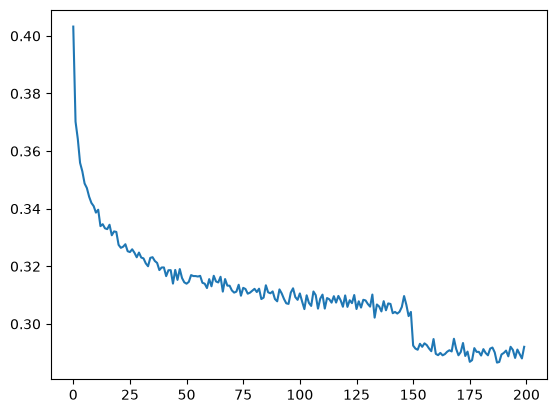

In [54]:
lossi_mean = torch.tensor(lossi).view(-1, 1000).mean(1)
plt.plot(lossi_mean)

In [29]:
class Embedding:
    
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

class Flatten:

    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out

    def parameters(self):
        return []

In [10]:
t = torch.tensor([[[1, 2],
                   [3, 4]],
                  [[5, 6],
                   [7, 8]]])
print(t.shape)
torch.flatten(t, start_dim=2)


torch.Size([2, 2, 2])


tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])

In [39]:
n_embd = 10
n_hidden = 200

# C = torch.randn((vocab_size, n_embd)) replaced with Embedding()
layers = [
    Embedding(vocab_size, n_embd), Flatten(),
    Linear((block_size * n_embd), n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    layers[-1].weight *= 0.1

parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

22097


In [40]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    x = Xb
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.8405
  10000/ 200000: 1.9577
  20000/ 200000: 2.1326
  30000/ 200000: 1.9746
  40000/ 200000: 1.8617
  50000/ 200000: 2.3109
  60000/ 200000: 2.0680
  70000/ 200000: 2.2803
  80000/ 200000: 1.8264
  90000/ 200000: 1.7933
 100000/ 200000: 1.7447
 110000/ 200000: 2.2477
 120000/ 200000: 2.0818
 130000/ 200000: 1.8580
 140000/ 200000: 1.8732
 150000/ 200000: 1.9251
 160000/ 200000: 2.0584
 170000/ 200000: 2.0322
 180000/ 200000: 1.9527
 190000/ 200000: 1.7601


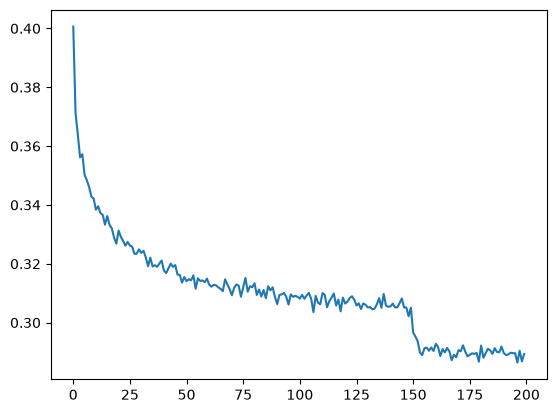

In [42]:
lossi_mean = torch.tensor(lossi).view(-1, 1000).mean(1)
plt.plot(lossi_mean)

In [30]:
class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [31]:
n_embd = 10
n_hidden = 200

model = Sequential([
    Embedding(vocab_size, n_embd), Flatten(),
    Linear((block_size * n_embd), n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

print(sum(p.nelement() for p in model.parameters()))
for p in model.parameters():
    p.requires_grad = True

22097


In [32]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    for p in model.parameters():
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in model.parameters():
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.9617
  10000/ 200000: 2.0023
  20000/ 200000: 1.6754
  30000/ 200000: 1.9989
  40000/ 200000: 2.0616
  50000/ 200000: 2.3697
  60000/ 200000: 1.9373
  70000/ 200000: 2.0445
  80000/ 200000: 2.3586
  90000/ 200000: 2.3770
 100000/ 200000: 1.6358
 110000/ 200000: 1.8494
 120000/ 200000: 2.3247
 130000/ 200000: 1.6883
 140000/ 200000: 1.8131
 150000/ 200000: 1.8425
 160000/ 200000: 2.0444
 170000/ 200000: 2.2901
 180000/ 200000: 2.0609
 190000/ 200000: 1.7411


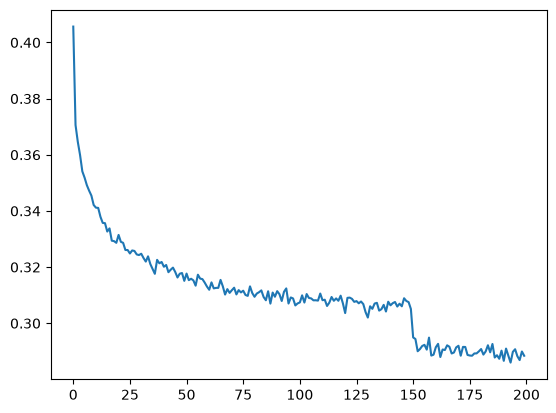

In [33]:
lossi_mean = torch.tensor(lossi).view(-1, 1000).mean(1)
plt.plot(lossi_mean)

In [34]:
for layer in model.layers:
    layer.training = False

In [35]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'dev': (Xdev, Ydev),
        'test': (Xte, Ytr)
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)

    print(f'{split} loss: {loss.item()}')

split_loss('train')
split_loss('dev')

train loss: 1.9180917739868164
dev loss: 2.0274996757507324


In [ ]:
3 character:
    params: 12097
    train loss: 2.059530735015869
    dev loss: 2.10799241065979

8 character:
    params: 22097
    train loss: 1.9180917739868164
    dev loss: 2.0274996757507324

In [36]:
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        x = torch.tensor([context])

        logits = model(x)
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1).item()
        out.append(itos[ix])
        context = context[1:] + [ix]
        if ix == 0:
            break
    print(''.join(out))


kyssam.
navia.
nidelle.
meabhay.
lucrytin.
leelalai.
kaistof.
jaxine.
nikalte.
gillan.
khebelre.
rohion.
naizayn.
yedavia.
micaeda.
anole.
dayla.
jalietta.
brynn.
geniyah.
